In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sohailkhan05/loan-risk-prediction/loan_risk_prediction_dataset.csv


# **1. Seleção e justificativa do Dataset**

Para o desenvolvimento deste projeto, foi utilizado o Loan Risk Prediction Dataset. A escolha desse conjunto de dados foi feita por ele apresentar características financeiras e demográficas de clientes (como idade, renda, score de crédito, tempo de experiência, etc.) e uma variável alvo que identifica o risco ou a aprovação do empréstimo (LoanApproved), permitindo aplicar técnicas avançadas de classificação binária utilizando o algoritmo SVM.

# **2. Importação das bibliotecas**

Nesta etapa, são importadas as bibliotecas necessárias para realizar a leitura e o tratamento dos dados, a preparação das informações para o modelo, o treinamento do algoritmo SVM e a avaliação e visualização dos resultados obtidos.

In [2]:
# Importamos a biblioteca pandas para carregar e manipular os dados em formato de tabela
import pandas as pd

# Importamos o NumPy para realizar operações numéricas de forma eficiente
import numpy as np

# Importamos o Matplotlib para criar e exibir gráficos
import matplotlib.pyplot as plt

# Importamos o Seaborn para facilitar a criação de gráficos estatísticos
import seaborn as sns

# Importamos a função utilizada para separar os dados em conjuntos de treino e teste
from sklearn.model_selection import train_test_split

# Importamos o GridSearchCV para testar diferentes combinações de parâmetros do modelo
from sklearn.model_selection import GridSearchCV

# Importamos o StandardScaler para padronizar a escala das variáveis numéricas
from sklearn.preprocessing import StandardScaler

# Importamos o SVC, que é o classificador SVM utilizado para realizar a classificação
from sklearn.svm import SVC

# Importamos métricas para avaliar o desempenho do modelo, como acurácia,
# relatório de classificação e matriz de confusão
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **3. Carregamento e exploração inicial dos dados** 
Como primeira etapa do tratamento dos dados, realizamos a leitura do dataset e verificamos suas primeiras linhas. Essa análise inicial permite compreender como as informações estão organizadas e identificar as principais características disponíveis para o desenvolvimento do modelo.

In [3]:
# Criamos uma variável para armazenar o caminho do dataset que será utilizado
arq_caminho = "/kaggle/input/datasets/sohailkhan05/loan-risk-prediction/loan_risk_prediction_dataset.csv"
# Utilizamos o pandas para ler o arquivo CSV e armazenar os dados em um DataFrame
df = pd.read_csv(arq_caminho)

# Exibimos as primeiras linhas do dataset para verificar como os dados estão organizados
print(df.head())

   Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  \
0   56  48353.0     31258.0        675.0               20  Female   
1   69  57462.0     23262.0        586.0                6    Male   
2   46  44219.0     26530.0        781.0               26    Male   
3   32  56307.0     11531.0        549.0               11    Male   
4   60  37034.0     27871.0        500.0               19  Female   

     Education           City EmploymentType  LoanApproved  
0  High School        Houston     Unemployed             0  
1  High School  San Francisco  Self-Employed             0  
2          PhD        Houston  Self-Employed             1  
3          NaN       New York     Unemployed             0  
4  High School        Chicago     Unemployed             0  


# **4. Estrutura e tipos de dados do Dataset**
Nesta etapa, verificamos a estrutura do DataFrame para identificar a quantidade de registros, o número de colunas, os tipos de dados presentes e a existência de possíveis valores ausentes.

In [4]:
# Exibimos informações do DataFrame, incluindo quantidade de registros,
# quantidade de colunas, tipos de dados e possíveis valores ausentes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


# **5. Análise estatística das variáveis**
Em seguida, realizamos uma análise estatística inicial das variáveis numéricas. São apresentados valores como quantidade de registros, média, desvio padrão, valores mínimo e máximo e quartis, permitindo observar a distribuição e a escala dos dados.

In [5]:
# Exibimos estatísticas descritivas das variáveis numéricas do dataset,
# como quantidade de registros, média, desvio padrão, mínimo e máximo
display(df.describe())

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


# **6. Verificação de valores nulos**
Antes de utilizar os dados no modelo, verificamos a existência de valores nulos em cada coluna. Essa etapa é importante porque dados ausentes podem exigir tratamento antes do treinamento do algoritmo.

In [6]:
# Contamos a quantidade de valores nulos existentes em cada coluna do dataset
qtd_nulos = df.isnull().sum()

# Exibimos o resultado para verificar se existem dados ausentes que precisam ser tratados
print(qtd_nulos)

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64


# **7. Tratamento de valores nulos, preparação e transformação dos dados**

Nesta etapa, tratamos os valores ausentes (NaN) identificados no dataset, pois o algoritmo SVM não aceita dados vazios. Preenchemos as colunas numéricas com a mediana e as categóricas com a moda. Em seguida, as informações textuais são padronizadas e transformadas em valores numéricos por meio do One-Hot Encoding, definindo as variáveis de entrada (X) e a variável alvo (y) da classificação.

In [7]:
# Como o dataset possui valores nulos (NaN) em colunas como 'Income', 'CreditScore' e 'Education',
# o SVM falharia. Precisamos tratá-los antes de prosseguir.

# Preenchemos os valores ausentes das colunas numéricas utilizando a MEDIANA de cada coluna.
colunas_numericas = ['Income', 'CreditScore']
for col in colunas_numericas:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Listamos as colunas categóricas (texto) presentes no dataset de empréstimos
colunas_categoricas = ['Gender', 'Education', 'City', 'EmploymentType']

# Removemos espaços extras, padronizamos a escrita e preenchemos os valores nulos com a MODA (valor mais frequente).
for col in colunas_categoricas:
    if col in df.columns:
        df[col] = df[col].str.strip().str.title()
        df[col] = df[col].fillna(df[col].mode()[0])

# Utilizamos One-Hot Encoding para transformar as colunas de texto em colunas numéricas.
# Cada categoria passa a ser representada por valores 0 ou 1.
df_encoded = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)

# Separamos as Features (X), que são as características utilizadas pelo modelo
# para realizar a previsão, como renda, idade e score de crédito.
# A coluna 'LoanApproved' não faz parte das Features porque será a variável que queremos prever.
X = df_encoded.drop('LoanApproved', axis=1)

# Separamos a variável alvo (y), que representa se o empréstimo foi aprovado ou não.
y = df_encoded['LoanApproved']

# **8. Separação dos dados e padronização das variáveis**
Nesta etapa, dividimos o dataset em conjuntos de treinamento e teste. Os dados de treinamento são utilizados para que o modelo aprenda os padrões existentes, enquanto os dados de teste são reservados para avaliar seu desempenho. Em seguida, aplicamos a padronização das variáveis para colocá-las em uma escala comparável.

In [8]:
# Dividimos os dados em 80% para treinamento e 20% para teste.
# O modelo utiliza os dados de treino para aprender e os dados de teste para ser avaliado.
# stratify=y mantém uma proporção semelhante das classes de aprovação nos dois conjuntos.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# O SVM é sensível à escala das variáveis.
# Como as características possuem valores muito diferentes entre si (ex: Renda vs Idade),
# utilizamos o StandardScaler para colocá-las em uma escala comparável.
scaler = StandardScaler()

# Calculamos os parâmetros de padronização utilizando os dados de treinamento
# e aplicamos essa transformação ao conjunto de treino.
X_train_scaled = scaler.fit_transform(X_train)

# Aplicamos aos dados de teste a mesma transformação calculada a partir dos dados de treino.
X_test_scaled = scaler.transform(X_test)

# **9. Definição e busca dos hiperparâmetros do SVM**

Nesta etapa, definimos diferentes combinações de hiperparâmetros do modelo SVM e utilizamos o GridSearchCV para avaliá-las automaticamente. A busca utiliza validação cruzada para identificar a combinação que apresenta a melhor acurácia média nos dados de treinamento

In [9]:
# Definimos os hiperparâmetros que serão testados pelo GridSearchCV:
# - C controla o quanto o modelo penaliza classificações incorretas.
# - gamma controla a influência de cada ponto quando utilizamos o kernel RBF.
# - kernel define o tipo de função utilizada pelo SVM para separar as classes.
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1],
    'kernel': ['linear', 'rbf']
}

# Criamos o classificador SVM e definimos um random_state para manter os resultados reproduzíveis
svm_model = SVC(random_state=42)

# O GridSearchCV testa as combinações definidas no param_grid.
# A validação cruzada divide os dados de treino em 5 partes para avaliar cada configuração.
# Como utilizamos scoring='accuracy', a configuração com maior acurácia média é selecionada.
# n_jobs=-1 permite utilizar todos os núcleos disponíveis do processador.
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Informamos que a busca pelas melhores combinações de parâmetros será iniciada
print("Iniciando a busca pelos melhores hiperparâmetros...")

# Executamos o treinamento e a busca pelas melhores combinações de hiperparâmetros
grid_search.fit(X_train_scaled, y_train)

# Exibimos os melhores parâmetros encontrados durante a busca
print("\nMELHORES HIPERPARÂMETROS ENCONTRADOS")
print(grid_search.best_params_)

# Exibimos a acurácia média obtida durante a validação cruzada
print(f"Acurácia média na validação cruzada: {grid_search.best_score_:.4f}")

Iniciando a busca pelos melhores hiperparâmetros...

MELHORES HIPERPARÂMETROS ENCONTRADOS
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Acurácia média na validação cruzada: 0.9247


# **10. Avaliação do modelo**
Após a definição dos melhores hiperparâmetros, utilizamos o modelo selecionado para realizar previsões no conjunto de teste. Em seguida, avaliamos seu desempenho por meio da acurácia e de outras métricas apresentadas no relatório de classificação.

In [10]:
# Selecionamos o melhor modelo encontrado pelo GridSearchCV
melhor_modelo = grid_search.best_estimator_

# Utilizamos o conjunto de teste, que não foi usado no treinamento,
# para realizar previsões em dados que o modelo ainda não tinha visto.
y_pred = melhor_modelo.predict(X_test_scaled)

# Calculamos e exibimos a acurácia final obtida no conjunto de teste
print(f"\nAcurácia final no conjunto de teste: {accuracy_score(y_test, y_pred):.4f}\n")

# Exibimos métricas detalhadas de classificação para o risco de crédito
print("Relatório de Classification Detalhado:")
print(classification_report(y_test, y_pred))


Acurácia final no conjunto de teste: 0.9210

Relatório de Classification Detalhado:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       770
           1       0.86      0.78      0.82       230

    accuracy                           0.92      1000
   macro avg       0.90      0.87      0.88      1000
weighted avg       0.92      0.92      0.92      1000



# **11. Matriz de confusão**
Nesta etapa, utilizamos uma matriz de confusão para representar visualmente o desempenho do modelo. Ela permite identificar a quantidade de classificações corretas e incorretas para as previsões de empréstimo aprovado ou negado, facilitando a análise dos resultados obtidos.

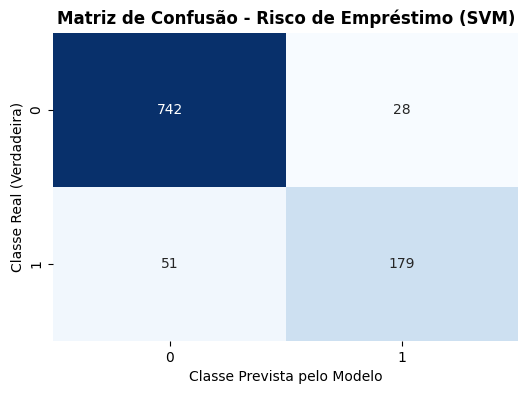

In [11]:
# Criamos uma área para exibir a matriz de confusão
plt.figure(figsize=(6, 4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    # Mostra a quantidade de previsões dentro de cada célula
    annot=True,
    # Exibe os valores como números inteiros
    fmt='d',
    # Utilizamos tons de azul para facilitar a visualização dos valores
    cmap='Blues',
    # Removemos a barra de cores lateral, pois os valores já aparecem nas células
    cbar=False
)

# Definimos o título do gráfico
plt.title('Matriz de Confusão - Risco de Empréstimo (SVM)', fontsize=12, fontweight='bold')
# Identificamos no eixo X as classes previstas pelo modelo
plt.xlabel('Classe Prevista pelo Modelo', fontsize=10)
# Identificamos no eixo Y as classes reais presentes nos dados
plt.ylabel('Classe Real (Verdadeira)', fontsize=10)

# Exibimos o gráfico
plt.show()

# **12. Relação entre Renda e Score de Crédito**
Por fim, utilizamos um gráfico de dispersão para observar visualmente a relação entre a Renda e o Score de Crédito dos clientes. As diferentes cores representam o status de aprovação do empréstimo, permitindo visualizar como essas características estão separadas geometricamente pelo modelo.

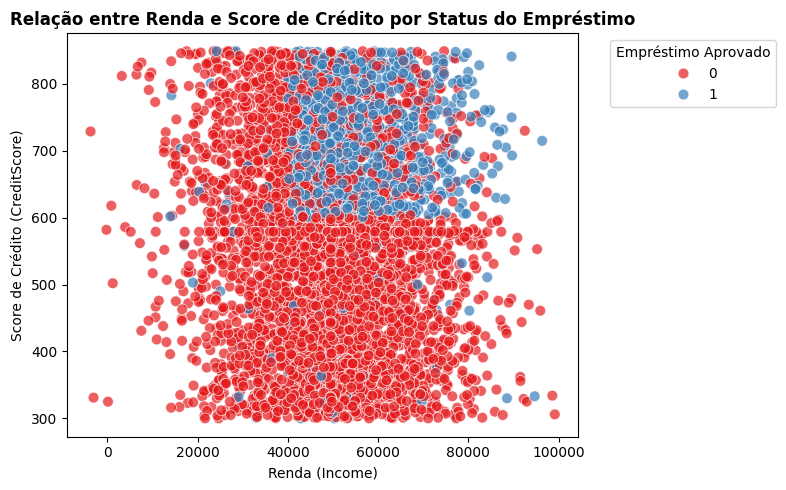

In [12]:
# Criamos uma área para exibir o gráfico de dispersão
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    # Utilizamos a renda como variável do eixo X
    x='Income',
    # Utilizamos o score de crédito como variável do eixo Y
    y='CreditScore',
    # Utilizamos o status do empréstimo para diferenciar as categorias pelas cores
    hue='LoanApproved',
    # Utilizamos uma paleta de cores distinta para facilitar a diferenciação das classes
    palette='Set1',
    # Deixamos os pontos levemente transparentes
    alpha=0.7,
    # Definimos o tamanho dos pontos no gráfico
    s=60
)

# Definimos o título do gráfico
plt.title('Relação entre Renda e Score de Crédito por Status do Empréstimo', fontsize=12, fontweight='bold')
# Identificamos o eixo X como Renda
plt.xlabel('Renda (Income)', fontsize=10)
# Identificamos o eixo Y como Score de Crédito
plt.ylabel('Score de Crédito (CreditScore)', fontsize=10)

# Exibimos uma legenda para identificar o status do empréstimo
plt.legend(title='Empréstimo Aprovado', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustamos automaticamente o espaçamento do gráfico
plt.tight_layout()

# Exibimos o gráfico
plt.show()